# M1 — Model 1 of 4: Random Forest (the baseline)

**Project:** Bio-Inspired Medicinal Plant Species Crowd-sourcing Using Goats
**Course:** CSC 3118 — Computer Science Project I
**Data:** `outputs_kamminga/windows_kamminga.npz`, made by `M1_1_Explore_and_Window.ipynb`

---

## The question M1 answers

*Is the goat eating during these 2 seconds?* If yes, the collar wakes the camera.
If no, the camera stays asleep and saves battery.

## Why a Random Forest comes first

A Random Forest can't read a raw signal. It needs a table of numbers. So we turn
each 2-second window into about 170 summary numbers: how much the collar shook,
how fast it rotated, how rhythmic the movement was, and so on. These are called
**hand-crafted features**, because a person decided what to measure.

That makes it the **honest baseline**. The three deep models that follow (1D CNN,
LSTM, CNN-LSTM) learn their own features from the raw signal. If they can't beat
a forest built on simple statistics, they are not worth their extra size on a
collar with a small battery.

**Run order:** Kernel → Restart Kernel and Run All Cells.
Put this notebook in **the same folder as `M1_1_Explore_and_Window.ipynb`**, so it
finds the `outputs_kamminga` folder next to it.

In [1]:
# =============================================================================
# CONFIGURATION
# =============================================================================
OUT_DIR = "outputs_kamminga"              # same folder M1_1 wrote into
DATA_FILE = "windows_kamminga.npz"

MODEL_NAME = "Random Forest"
TAG = "M1_2_RandomForest"                 # used in every saved filename

N_TREES = 300
RANDOM_SEED = 42

# Small search over two settings, scored on the VALIDATION set only.
#   max_depth        how deep each tree may grow (None = until pure)
#   min_samples_leaf smallest group a leaf may hold (bigger = smoother trees)
GRID = [
    {"max_depth": None, "min_samples_leaf": 1},
    {"max_depth": None, "min_samples_leaf": 5},
    {"max_depth": 20,   "min_samples_leaf": 1},
    {"max_depth": 20,   "min_samples_leaf": 5},
]

In [2]:
# =============================================================================
# IMPORTS
# =============================================================================
import os, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score,
                             confusion_matrix, precision_recall_curve)

RESULTS_DIR = os.path.join(OUT_DIR, "results")
FIG_DIR = os.path.join(OUT_DIR, "figures")
MODEL_DIR = os.path.join(OUT_DIR, "models")
for d in (RESULTS_DIR, FIG_DIR, MODEL_DIR):
    os.makedirs(d, exist_ok=True)

# One quiet, consistent chart style for every figure in the report.
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 10,
})
MAIN = "#2a6f97"      # one colour for the model's own marks
MUTED = "#9aa5b1"     # reference lines and "the rest"

print("Results ->", os.path.abspath(RESULTS_DIR))

Results -> c:\Users\OKEDI\Downloads\outputs_kamminga\results


In [3]:
# =============================================================================
# LOAD THE WINDOWS
# =============================================================================
path = os.path.join(OUT_DIR, DATA_FILE)
if not os.path.exists(path):
    raise FileNotFoundError(
        f"Cannot find {os.path.abspath(path)}\n"
        "Run M1_1_Explore_and_Window.ipynb first, and keep this notebook in the "
        "same folder as that one.")

d = np.load(path, allow_pickle=True)
X = d["X"]                        # (windows, 400, 6), raw sensor units
y = d["y"].astype(np.int64)       # 1 = eating, 0 = not eating
labels = d["labels"]              # original activity name, for error analysis
splits = d["splits"]
channels = [str(c) for c in d["channels"]]
FS = int(d["sample_rate_hz"][0])

tr, va, te = (splits == "train"), (splits == "val"), (splits == "test")
print(f"Windows: {len(X):,}   shape {X.shape}   {FS} Hz   channels {channels}")
for name, m in [("train", tr), ("val", va), ("test", te)]:
    print(f"  {name:<5} {m.sum():>7,} windows   eating {y[m].mean():6.1%}")

Windows: 39,775   shape (39775, 400, 6)   200 Hz   channels ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
  train  26,375 windows   eating  21.6%
  val     7,543 windows   eating  23.8%
  test    5,857 windows   eating  10.1%


### A note on the split, for your report

The eating share is not the same in every split (about 22% in train, 24% in
validation, 10% in test). That happens because the split is done by **segment**,
and grazing segments vary a lot in length. A few long grazing bouts decide where
most grazing windows end up.

This is the price of splitting honestly. Splitting by window would balance the
numbers perfectly and leak overlapping windows into the test set. All four models
use this same split, so the comparison between them stays fair.

It does change one thing: **precision on the test set will look lower** than on
validation, because there are fewer real eating windows for a correct alarm to
land on. That is why we report F1 and PR-AUC as well as accuracy.

## Step 1 — Turn each window into a row of numbers

For each of 8 signals (the 6 sensor axes, plus the overall strength of
acceleration and of rotation), we measure:

| Group | Features | What it captures |
|---|---|---|
| Level | mean, median, min, max, range | Head position: grazing keeps the head low |
| Spread | std, IQR, RMS | How much the collar is moving |
| Shape | skewness, kurtosis | Whether movement comes in sharp bursts or smooth swings |
| Change | mean absolute jerk, zero-crossing rate | How jerky or rhythmic the motion is |
| Frequency | dominant frequency, energy in 5 bands, spectral entropy | Chewing and stepping each have a rhythm |

We also measure how the three axes move together (6 correlations).
That gives 8 × 20 + 6 = **166 features per window**.

The work is done in chunks so it fits comfortably in laptop memory.

In [4]:
# =============================================================================
# FEATURE EXTRACTION
# =============================================================================
BANDS = [(0, 2), (2, 5), (5, 10), (10, 20), (20, FS / 2)]
SIG_NAMES = channels + ["acc_mag", "gyr_mag"]
STATS = (["mean", "median", "min", "max", "range", "std", "iqr", "rms",
          "skew", "kurt", "jerk", "zcr", "dom_freq"]
         + [f"band_{int(a)}_{int(b)}Hz" for a, b in BANDS]
         + ["spec_entropy", "p90"])
PAIRS = [(0, 1), (0, 2), (1, 2), (3, 4), (3, 5), (4, 5)]

FEATURE_NAMES = ([f"{s}_{st}" for s in SIG_NAMES for st in STATS]
                 + [f"corr_{channels[i]}_{channels[j]}" for i, j in PAIRS])


def extract_features(Xb, fs=FS):
    """Xb: (n, T, 6) raw windows  ->  (n, 166) feature table."""
    Xb = Xb.astype(np.float64)
    n, T, _ = Xb.shape
    acc_mag = np.linalg.norm(Xb[:, :, 0:3], axis=2, keepdims=True)
    gyr_mag = np.linalg.norm(Xb[:, :, 3:6], axis=2, keepdims=True)
    S = np.concatenate([Xb, acc_mag, gyr_mag], axis=2)          # (n, T, 8)

    mean = S.mean(1)
    std = S.std(1)
    cen = S - mean[:, None, :]
    q25, q50, q75, q90 = np.percentile(S, [25, 50, 75, 90], axis=1)
    mn, mx = S.min(1), S.max(1)
    rms = np.sqrt((S ** 2).mean(1))
    eps = 1e-9
    skew = (cen ** 3).mean(1) / (std ** 3 + eps)
    kurt = (cen ** 4).mean(1) / (std ** 4 + eps) - 3.0
    jerk = np.abs(np.diff(S, axis=1)).mean(1)
    zcr = (np.diff(np.signbit(cen), axis=1)).mean(1)

    power = np.abs(np.fft.rfft(cen, axis=1)) ** 2              # (n, F, 8)
    freqs = np.fft.rfftfreq(T, 1.0 / fs)
    total = power.sum(1) + eps
    dom = freqs[power[:, 1:, :].argmax(1) + 1]
    bands = [power[:, (freqs >= a) & (freqs < b), :].sum(1) / total
             for a, b in BANDS]
    p = power / total[:, None, :]
    ent = -(p * np.log(p + eps)).sum(1) / np.log(power.shape[1])

    per_signal = [mean, q50, mn, mx, mx - mn, std, q75 - q25, rms,
                  skew, kurt, jerk, zcr, dom] + bands + [ent, q90]
    block = np.stack(per_signal, axis=2)                         # (n, 8, 20)
    block = block.reshape(n, -1)                                 # signal-major

    corrs = [(cen[:, :, i] * cen[:, :, j]).mean(1) / (std[:, i] * std[:, j] + eps)
             for i, j in PAIRS]
    return np.concatenate([block, np.stack(corrs, axis=1)], axis=1).astype(np.float32)


def features_in_chunks(Xall, chunk=2000):
    out = []
    for s in range(0, len(Xall), chunk):
        out.append(extract_features(Xall[s:s + chunk]))
    return np.concatenate(out)


t0 = time.time()
F = features_in_chunks(X)
feat_seconds = time.time() - t0

assert F.shape[1] == len(FEATURE_NAMES), (F.shape, len(FEATURE_NAMES))
assert np.isfinite(F).all(), "non-finite feature values"
print(f"Feature table: {F.shape}   ({feat_seconds:.1f}s, "
      f"{1000 * feat_seconds / len(X):.3f} ms per window)")
pd.DataFrame(F[:5], columns=FEATURE_NAMES).iloc[:, :8]

Feature table: (39775, 166)   (23.3s, 0.585 ms per window)


,ax_mean,ax_median,ax_min,ax_max,ax_range,ax_std,ax_iqr,ax_rms
0,2.099374,1.928530,-2.106900,7.99903,10.105930,1.866935,2.629432,2.809416
1,2.890268,2.744950,-1.017540,8.12831,9.145850,1.804519,2.476800,3.407336
2,2.828025,2.851495,-1.017540,8.12831,9.145850,1.619117,2.011127,3.258721
3,3.043168,3.032255,-0.268151,6.66067,6.928821,1.339039,1.656185,3.324740
4,3.083456,3.069370,-0.596156,7.29034,7.886496,1.889531,3.125630,3.616356


## Step 2 — Choose the forest's settings on the validation set

We try four settings and keep the one with the best **F1 on validation**.
The test set is not touched here. If you pick settings by looking at the test
score, the test score stops being an honest estimate.

`class_weight="balanced"` tells the forest that a missed eating window counts
more than a wrongly flagged one, in proportion to how rare eating is. This is the
Random Forest version of the weighted loss the deep models will use.

In [5]:
# =============================================================================
# SETTINGS SEARCH  (validation only)
# =============================================================================
search = []
best = None
for g in GRID:
    t0 = time.time()
    rf = RandomForestClassifier(n_estimators=N_TREES, class_weight="balanced",
                                n_jobs=-1, random_state=RANDOM_SEED, **g)
    rf.fit(F[tr], y[tr])
    p_val = rf.predict_proba(F[va])[:, 1]
    f1 = f1_score(y[va], (p_val >= 0.5).astype(int))
    secs = time.time() - t0
    search.append({**g, "val_f1": f1, "fit_seconds": secs})
    print(f"  max_depth={str(g['max_depth']):<5} min_leaf={g['min_samples_leaf']}"
          f"   val F1 = {f1:.4f}   ({secs:.0f}s)")
    if best is None or f1 > best[0]:
        best = (f1, g, rf, p_val)

best_val_f1, best_params, model, p_val = best
print(f"\nChosen: {best_params}   val F1 = {best_val_f1:.4f}")
pd.DataFrame(search)

  max_depth=None  min_leaf=1   val F1 = 0.9121   (23s)
  max_depth=None  min_leaf=5   val F1 = 0.9350   (23s)
  max_depth=20    min_leaf=1   val F1 = 0.9276   (21s)
  max_depth=20    min_leaf=5   val F1 = 0.9359   (21s)

Chosen: {'max_depth': 20, 'min_samples_leaf': 5}   val F1 = 0.9359


,max_depth,min_samples_leaf,val_f1,fit_seconds
0,NaN,1,0.912085,23.207247
1,NaN,5,0.934985,22.587702
2,20.0,1,0.927553,21.115396
3,20.0,5,0.935862,21.091606


## Step 3 — Choose the alarm threshold on validation

The forest gives a probability between 0 and 1. The usual rule is "eating if
above 0.5", but 0.5 is arbitrary. We slide the threshold and keep the one with
the best F1 on **validation**, then apply that fixed number to test.

On the collar this threshold is a real design knob. A lower one fires the
camera more often: fewer missed bites, more wasted photos and battery.

In [6]:
# =============================================================================
# THRESHOLD CHOSEN ON VALIDATION
# =============================================================================
thresholds = np.round(np.arange(0.05, 0.96, 0.01), 2)
val_f1s = [f1_score(y[va], (p_val >= t).astype(int), zero_division=0)
           for t in thresholds]
val_f1s = np.array(val_f1s)
# If several thresholds tie for best, take the one nearest 0.5 (least extreme).
tied = thresholds[val_f1s >= val_f1s.max() - 1e-9]
THRESHOLD = float(tied[np.argmin(np.abs(tied - 0.5))])
print(f"Best validation threshold: {THRESHOLD:.2f}   "
      f"(val F1 {val_f1s.max():.4f}, vs {val_f1s[np.argmin(np.abs(thresholds - 0.5))]:.4f} at 0.50)")

Best validation threshold: 0.44   (val F1 0.9433, vs 0.9359 at 0.50)


## Step 4 — The test set, once

Everything above used train and validation only. This is the first and only time
the test set is used.

In [7]:
# =============================================================================
# TEST-SET EVALUATION
# =============================================================================
t0 = time.time()
p_test = model.predict_proba(F[te])[:, 1]
predict_seconds = time.time() - t0


def metrics_at(p, t):
    pred = (p >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y[te], pred, labels=[0, 1]).ravel()
    return {
        "threshold": float(t),
        "accuracy": float(accuracy_score(y[te], pred)),
        "precision": float(precision_score(y[te], pred, zero_division=0)),
        "recall": float(recall_score(y[te], pred, zero_division=0)),
        "f1": float(f1_score(y[te], pred, zero_division=0)),
        "specificity": float(tn / (tn + fp)) if (tn + fp) else 0.0,
        "confusion_matrix": [[int(tn), int(fp)], [int(fn), int(tp)]],
    }


test_tuned = metrics_at(p_test, THRESHOLD)
test_05 = metrics_at(p_test, 0.5)
roc_auc = float(roc_auc_score(y[te], p_test))
pr_auc = float(average_precision_score(y[te], p_test))

rows = []
for k in ["accuracy", "precision", "recall", "specificity", "f1"]:
    rows.append({"metric": k, f"threshold {THRESHOLD:.2f} (chosen)": test_tuned[k],
                 "threshold 0.50": test_05[k]})
rows.append({"metric": "ROC-AUC", f"threshold {THRESHOLD:.2f} (chosen)": roc_auc,
             "threshold 0.50": roc_auc})
rows.append({"metric": "PR-AUC", f"threshold {THRESHOLD:.2f} (chosen)": pr_auc,
             "threshold 0.50": pr_auc})
print(f"TEST SET  ({te.sum():,} windows, {y[te].sum():,} eating)\n")
pd.DataFrame(rows).set_index("metric").round(4)

TEST SET  (5,857 windows, 590 eating)



,threshold 0.44 (chosen),threshold 0.50
metric,,
accuracy,0.9592,0.9664
precision,0.7300,0.7803
recall,0.9441,0.9271
specificity,0.9609,0.9708
f1,0.8234,0.8474
ROC-AUC,0.9913,0.9913
PR-AUC,0.9453,0.9453


### How to read these numbers

- **Recall** — of all the real eating moments, how many did we catch? A missed
  bite is a plant we never photograph. This is the one that matters most.
- **Precision** — of all the times the camera fired, how many were real eating?
  Low precision wastes battery and storage on useless photos.
- **F1** — one number that balances the two. This is the headline for comparing
  the four models.
- **Accuracy** — shown because people expect it, but misleading here. A model
  that always says "not eating" scores about 90% on this test set and is useless.
- **PR-AUC** — how good the model is across *all* thresholds, not just the one we
  picked. The fairest single number for a rare class. A random guess scores
  about 0.10 here, the share of eating windows in test.

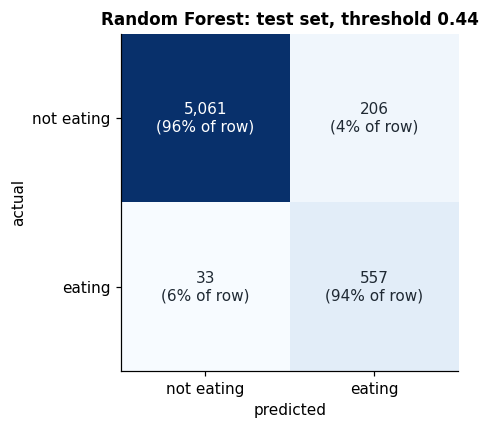

In [8]:
# =============================================================================
# FIGURE: CONFUSION MATRIX
# =============================================================================
cm = np.array(test_tuned["confusion_matrix"])
fig, ax = plt.subplots(figsize=(4.6, 4.0))
ax.imshow(cm, cmap="Blues")
ax.grid(False)
names = ["not eating", "eating"]
ax.set_xticks([0, 1], names); ax.set_yticks([0, 1], names)
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
for i in range(2):
    for j in range(2):
        share = cm[i, j] / cm[i].sum() if cm[i].sum() else 0
        ax.text(j, i, f"{cm[i, j]:,}\n({share:.0%} of row)", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() * 0.55 else "#1f2933", fontsize=10)
ax.set_title(f"{MODEL_NAME}: test set, threshold {THRESHOLD:.2f}")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"{TAG}_confusion.png"))
plt.show()

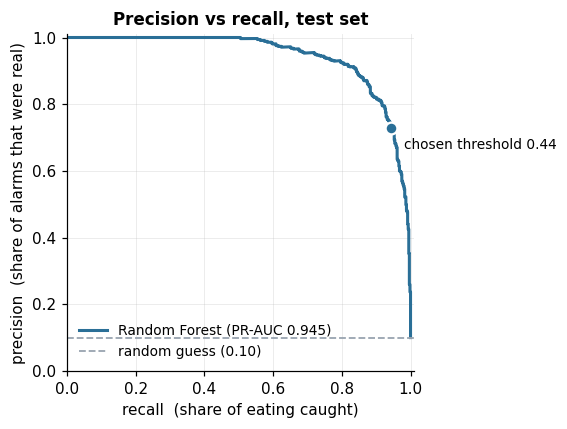

In [9]:
# =============================================================================
# FIGURE: PRECISION-RECALL CURVE
# =============================================================================
prec, rec, _ = precision_recall_curve(y[te], p_test)
fig, ax = plt.subplots(figsize=(5.2, 4.0))
ax.plot(rec, prec, color=MAIN, linewidth=2, label=f"{MODEL_NAME} (PR-AUC {pr_auc:.3f})")
ax.axhline(y[te].mean(), color=MUTED, linewidth=1.2, linestyle="--",
           label=f"random guess ({y[te].mean():.2f})")
ax.scatter([test_tuned["recall"]], [test_tuned["precision"]], s=60, color=MAIN,
           edgecolor="white", linewidth=1.5, zorder=3)
ax.annotate(f"chosen threshold {THRESHOLD:.2f}",
            (test_tuned["recall"], test_tuned["precision"]),
            xytext=(8, -14), textcoords="offset points", fontsize=9)
ax.set_xlim(0, 1.01); ax.set_ylim(0, 1.01)
ax.set_xlabel("recall  (share of eating caught)")
ax.set_ylabel("precision  (share of alarms that were real)")
ax.set_title("Precision vs recall, test set")
ax.legend(loc="lower left", frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"{TAG}_pr_curve.png"))
plt.show()

## Step 5 — What does the model confuse with eating?

The table below breaks the test set down by the **original activity**. For
grazing, the "flagged as eating" column is recall. For every other activity it
is the false-alarm rate.

This is the most useful table for your discussion. It tells you *which*
behaviour fools the collar, not just how often it's fooled.

                windows flagged_as_eating
activity                                 
grazing             590             94.4%
scratch_biting       54             48.1%
fighting             44             11.4%
standing           3240              3.6%
walking             819              3.5%
lying               988              3.0%
running              57              0.0%
trotting             65              0.0%


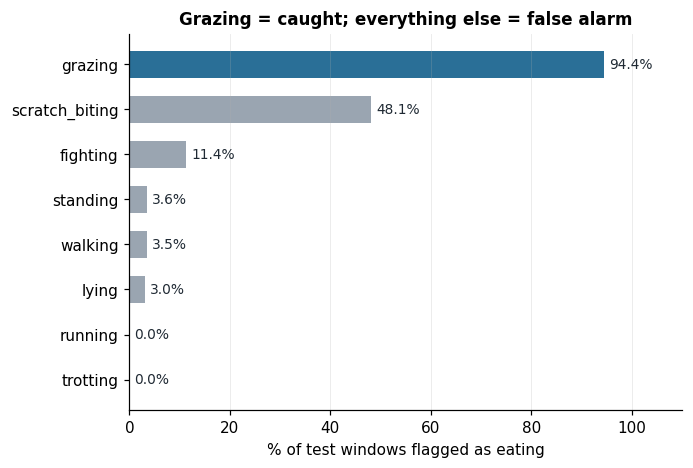

In [10]:
# =============================================================================
# ERROR ANALYSIS BY ORIGINAL ACTIVITY
# =============================================================================
pred_te = (p_test >= THRESHOLD).astype(int)
by_act = (pd.DataFrame({"activity": labels[te], "flagged": pred_te})
            .groupby("activity")["flagged"].agg(windows="size", flagged_as_eating="mean")
            .sort_values("flagged_as_eating", ascending=False))
display_tbl = by_act.copy()
display_tbl["flagged_as_eating"] = (display_tbl["flagged_as_eating"] * 100).round(1).astype(str) + "%"
print(display_tbl.to_string())

fig, ax = plt.subplots(figsize=(6.4, 0.42 * len(by_act) + 1.0))
acts = by_act.index.tolist()[::-1]
vals = by_act["flagged_as_eating"].values[::-1] * 100
colors = [MAIN if a == "grazing" else MUTED for a in acts]
ax.barh(acts, vals, color=colors, height=0.6)
for yi, v in enumerate(vals):
    ax.text(v + 1, yi, f"{v:.1f}%", va="center", fontsize=9, color="#1f2933")
ax.set_xlim(0, 110)
ax.set_xlabel("% of test windows flagged as eating")
ax.set_title("Grazing = caught; everything else = false alarm")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"{TAG}_by_activity.png"))
plt.show()

## Step 6 — Which features did the forest rely on?

A forest records how much each feature helped it split eating from not eating.
This is one of the model's big advantages: you can **explain** it. The deep
models will need Grad-CAM or SHAP to answer the same question.

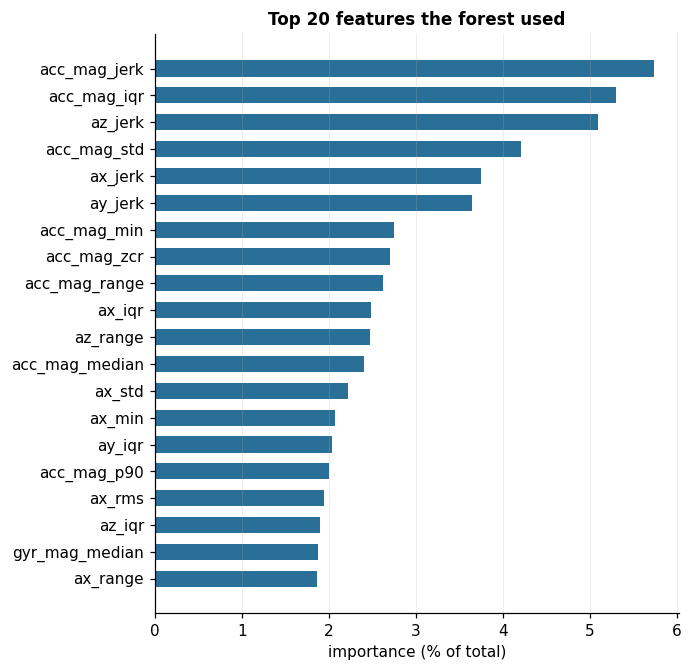

Importance grouped by signal:
  acc_mag                   32.7%
  ax                        19.0%
  az                        16.0%
  ay                        13.4%
  gyr_mag                    6.0%
  gz                         5.3%
  gy                         3.1%
  gx                         2.7%
  cross-axis correlations    1.9%


In [11]:
# =============================================================================
# FIGURE: TOP 20 FEATURES
# =============================================================================
imp = pd.Series(model.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False)
top = imp.head(20)[::-1]

fig, ax = plt.subplots(figsize=(6.4, 6.2))
ax.barh(top.index, top.values * 100, color=MAIN, height=0.6)
ax.set_xlabel("importance (% of total)")
ax.set_title("Top 20 features the forest used")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"{TAG}_feature_importance.png"))
plt.show()

print("Importance grouped by signal:")
by_sig = {s: imp[[f"{s}_{st}" for st in STATS]].sum() for s in SIG_NAMES}
by_sig["cross-axis correlations"] = imp[[n for n in FEATURE_NAMES if n.startswith("corr_")]].sum()
for s, v in sorted(by_sig.items(), key=lambda kv: -kv[1]):
    print(f"  {s:<24} {v:6.1%}")

## Step 7 — Could it run on the collar?

Accuracy alone doesn't pick the winner. The model has to fit on a
microcontroller and decide fast enough to wake the camera before the bite is
over. We measure:

- **Model size** on disk
- **Decision time** per window on this laptop, *including* feature extraction
  (the collar would have to compute the 166 features too)
- **Tree nodes**, which is what the collar's memory would hold

In [12]:
# =============================================================================
# SIZE AND SPEED
# =============================================================================
model_path = os.path.join(MODEL_DIR, f"{TAG}.joblib")
joblib.dump(model, model_path, compress=3)
size_mb = os.path.getsize(model_path) / 1e6
n_nodes = int(sum(t.tree_.node_count for t in model.estimators_))

# Time the full pipeline (raw window -> features -> decision) on 500 windows,
# one window at a time, the way the collar would see them.
idx = np.where(te)[0][:500]
model.set_params(n_jobs=1)        # one core, like a microcontroller
t0 = time.time()
for i in idx:
    f = extract_features(X[i:i + 1])
    model.predict_proba(f)
ms_per_window = 1000 * (time.time() - t0) / len(idx)
model.set_params(n_jobs=-1)

print(f"Model file:         {size_mb:.2f} MB  ({model_path})")
print(f"Total tree nodes:   {n_nodes:,}")
print(f"Decision time:      {ms_per_window:.2f} ms per window, one at a time, on this laptop")
print(f"Window length:      {1000 * X.shape[1] / FS:.0f} ms")
print()
print("Model size matters for the collar. A microcontroller like the ESP32-S3 has")
print("a few MB of flash. If this file is much bigger than that, the forest needs")
print("fewer or shallower trees before it could run on the collar. That trade-off")
print("goes in the comparison table.")

Model file:         6.19 MB  (outputs_kamminga\models\M1_2_RandomForest.joblib)
Total tree nodes:   204,998
Decision time:      23.08 ms per window, one at a time, on this laptop
Window length:      2000 ms

Model size matters for the collar. A microcontroller like the ESP32-S3 has
a few MB of flash. If this file is much bigger than that, the forest needs
fewer or shallower trees before it could run on the collar. That trade-off
goes in the comparison table.


In [13]:
# =============================================================================
# SAVE RESULTS  (read later by the comparison notebook)
# =============================================================================
results = {
    "model": MODEL_NAME,
    "tag": TAG,
    "type": "classical ML, hand-crafted features",
    "input": f"{F.shape[1]} features per 2 s window",
    "chosen_settings": {k: (None if v is None else v) for k, v in best_params.items()},
    "n_trees": N_TREES,
    "val_f1_at_0.5": float(best_val_f1),
    "threshold": THRESHOLD,
    "test": {**test_tuned, "roc_auc": roc_auc, "pr_auc": pr_auc},
    "test_at_0.5": test_05,
    "model_size_mb": round(size_mb, 3),
    "complexity": {"tree_nodes": n_nodes},
    "ms_per_window": round(ms_per_window, 3),
    "train_seconds": round(sum(s["fit_seconds"] for s in search), 1),
    "test_windows": int(te.sum()),
    "test_eating_windows": int(y[te].sum()),
    "false_alarm_by_activity": {a: float(v) for a, v in by_act["flagged_as_eating"].items()},
}
res_path = os.path.join(RESULTS_DIR, f"{TAG}.json")
with open(res_path, "w") as fh:
    json.dump(results, fh, indent=2)
print(f"Saved: {res_path}")
print(json.dumps({k: results[k] for k in ["model", "threshold", "model_size_mb", "ms_per_window"]}, indent=2))
print(f"test F1 {results['test']['f1']:.4f}   recall {results['test']['recall']:.4f}   "
      f"precision {results['test']['precision']:.4f}   PR-AUC {pr_auc:.4f}")

Saved: outputs_kamminga\results\M1_2_RandomForest.json
{
  "model": "Random Forest",
  "threshold": 0.44,
  "model_size_mb": 6.193,
  "ms_per_window": 23.085
}
test F1 0.8234   recall 0.9441   precision 0.7300   PR-AUC 0.9453


---

## What to write in your report about this model

1. **Method.** 166 hand-crafted time and frequency features per 2-second window,
   a 300-tree Random Forest with balanced class weights, settings and threshold
   chosen on validation, one evaluation on a held-out test set split by segment.
2. **Result.** Quote test F1, recall, precision and PR-AUC. Don't lead with accuracy.
3. **Errors.** Name the activity most often mistaken for grazing, from the Step 5
   chart, and give a physical reason (similar head-down posture, similar rhythm).
4. **Explainability.** Name the top two or three features and what they mean for
   a goat's body.
5. **Deployability.** Model size and decision time. These decide whether it can
   live on the collar.

## Next

`M1_3_1D_CNN.ipynb`, the first deep model. It reads the raw 400 × 6 signal
directly, with no hand-crafted features, from the same file and the same split.
Its results land in the same `results` folder, so the final comparison notebook
can put all four side by side.